# Audio Feature Extraction Pipeline

This notebook builds the visual used for the report pipeline figure.
It loads one example waveform, runs the same feature stages used in the project, and saves a compact waveform-to-feature diagram into `notebooks/plots/`.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torchaudio


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not find repo root with pyproject.toml.")


ROOT = find_repo_root(Path.cwd().resolve())
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

plt.style.use("seaborn-v0_8-whitegrid")
torch.manual_seed(7)

ROOT=/Users/pawelp/Desktop/education/pw/deepl/speech-recognition


In [ ]:
from speech_recognition.features import PCENFeatures, WaveformLoader

In [2]:
sample_label = "yes"
audio_root = (
    ROOT
    / "data"
    / "kaggle_speech_commands"
    / "tensorflow-speech-recognition-challenge"
    / "train"
    / "audio"
)
sample_paths = sorted((audio_root / sample_label).glob("*.wav"))
if not sample_paths:
    raise RuntimeError(f"No wav files found for label {sample_label!r} in {audio_root}.")

sample_path = sample_paths[0]
sample_rate = 16000
target_seconds = 1.0
n_fft = 1024
hop_length = 160
n_mels = 128

waveform_loader = WaveformLoader(sample_rate=sample_rate, target_seconds=target_seconds)
waveform = waveform_loader([sample_path]).squeeze(0)

spectrogram = torchaudio.transforms.Spectrogram(
    n_fft=n_fft,
    hop_length=hop_length,
    win_length=n_fft,
    window_fn=torch.hann_window,
    power=2.0,
    center=True,
)(waveform)

mel_scale = torchaudio.transforms.MelScale(
    n_mels=n_mels,
    sample_rate=sample_rate,
    n_stft=n_fft // 2 + 1,
)
mel_power = mel_scale(spectrogram)
log_mel = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80.0)(mel_power)
pcen = PCENFeatures(sample_rate=sample_rate, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)(
    waveform
)

time = torch.linspace(0.0, target_seconds, waveform.shape[-1])
spec_time = torch.linspace(0.0, target_seconds, spectrogram.shape[-1])
mel_time = torch.linspace(0.0, target_seconds, mel_power.shape[-1])

print(f"sample={sample_path.name}")
print(f"waveform shape={tuple(waveform.shape)}")
print(f"spectrogram shape={tuple(spectrogram.shape)}")
print(f"mel shape={tuple(mel_power.shape)}")
print(f"pcen shape={tuple(pcen.shape)}")

sample=004ae714_nohash_0.wav
waveform shape=(1, 16000)
spectrogram shape=(1, 513, 101)
mel shape=(1, 128, 101)
pcen shape=(1, 128, 101)


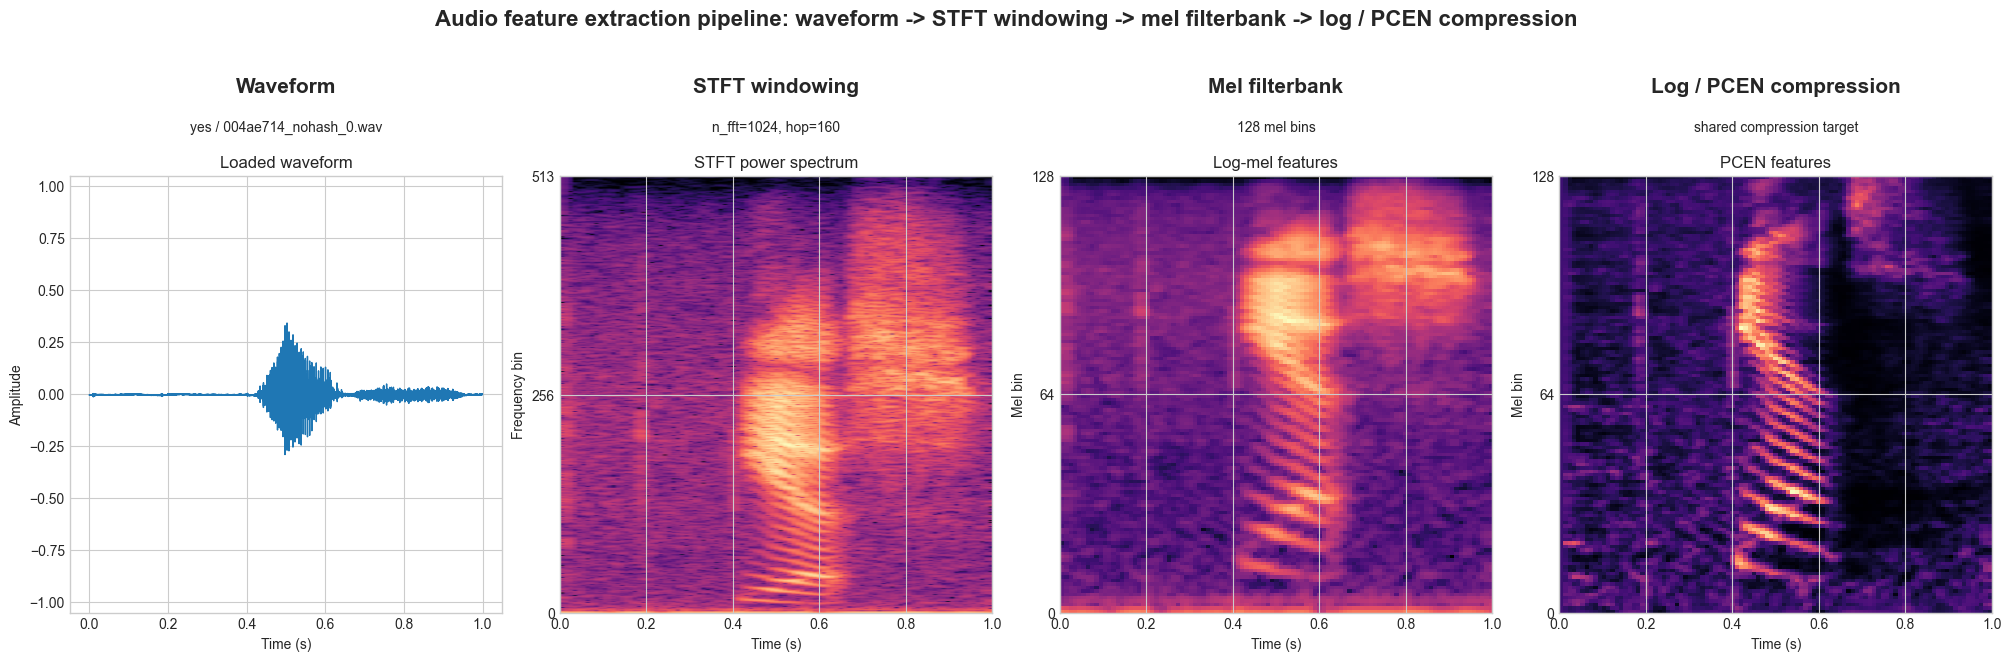

saved /Users/pawelp/Desktop/education/pw/deepl/speech-recognition/notebooks/plots/audio_feature_extraction_pipeline.png


In [3]:
fig = plt.figure(figsize=(20, 6.5), constrained_layout=True)
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 4.0])

top_axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
bottom_axes = [fig.add_subplot(gs[1, i]) for i in range(4)]

stage_labels = [
    "Waveform",
    "STFT windowing",
    "Mel filterbank",
    "Log / PCEN compression",
]
for axis, label in zip(top_axes, stage_labels, strict=True):
    axis.axis("off")
    axis.text(0.5, 0.55, label, ha="center", va="center", fontsize=15, fontweight="bold")

top_axes[0].text(
    0.5, 0.18, f"{sample_label} / {sample_path.name}", ha="center", va="center", fontsize=10
)
top_axes[1].text(
    0.5, 0.18, f"n_fft={n_fft}, hop={hop_length}", ha="center", va="center", fontsize=10
)
top_axes[2].text(0.5, 0.18, f"{n_mels} mel bins", ha="center", va="center", fontsize=10)
top_axes[3].text(0.5, 0.18, "shared compression target", ha="center", va="center", fontsize=10)

bottom_axes[0].plot(time.cpu(), waveform.squeeze(0).cpu(), color="#1f77b4", linewidth=1.0)
bottom_axes[0].set_ylabel("Amplitude")
bottom_axes[0].set_xlabel("Time (s)")
bottom_axes[0].set_ylim(-1.05, 1.05)
bottom_axes[0].set_title("Loaded waveform")

bottom_axes[1].imshow(
    spectrogram.squeeze(0).cpu().log10().clamp(min=-8).numpy(),
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=[spec_time.min().item(), spec_time.max().item(), 0, spectrogram.shape[-2]],
)
bottom_axes[1].set_ylabel("Frequency bin")
bottom_axes[1].set_xlabel("Time (s)")
bottom_axes[1].set_title("STFT power spectrum")

bottom_axes[2].imshow(
    log_mel.squeeze(0).cpu().numpy(),
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=[mel_time.min().item(), mel_time.max().item(), 0, n_mels],
)
bottom_axes[2].set_ylabel("Mel bin")
bottom_axes[2].set_xlabel("Time (s)")
bottom_axes[2].set_title("Log-mel features")

bottom_axes[3].imshow(
    pcen.squeeze(0).cpu().numpy(),
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=[mel_time.min().item(), mel_time.max().item(), 0, n_mels],
)
bottom_axes[3].set_ylabel("Mel bin")
bottom_axes[3].set_xlabel("Time (s)")
bottom_axes[3].set_title("PCEN features")

for axis in bottom_axes[1:]:
    axis.set_yticks(
        [0, axis.images[0].get_array().shape[0] // 2, axis.images[0].get_array().shape[0]]
    )

fig.suptitle(
    (
        "Audio feature extraction pipeline: "
        "waveform -> STFT windowing -> mel filterbank -> log / PCEN compression"
    ),
    fontsize=16,
    fontweight="bold",
)

output_dir = ROOT / "notebooks" / "plots"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "audio_feature_extraction_pipeline.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"saved {output_path}")